<a href="https://colab.research.google.com/github/mikakia/AdvanceML_Labs/blob/examples/Lab1-basics_intro/2_1_simple%20example(neural_network).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Optimization refers to the task of either minimizing or maximizing some function f(x) by altering x.


---
The function we want to minimize or maximize is called the objective function or criterion.



In [19]:
# Step 0: Import Necessary Libraries
import torch  # Import PyTorch for deep learning
import torch.nn as nn  # Import the neural network module
import torch.nn.functional as F  # Import functional interface
import torch.optim as optim  # Import the optimization algorithms
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation

# Step 1: Create Synthetic Dataset
np.random.seed(0)  # Set random seed for reproducibility
data = np.random.rand(20, 3)  # Generate random data: 20 samples and 3 features
df = pd.DataFrame(data, columns=['Feature1', 'Feature2', 'Label'])  # Convert to DataFrame for easy handling
# Convert features and labels to PyTorch tensors for model training
X = torch.tensor(df[['Feature1', 'Feature2']].values, dtype=torch.float32)
Y = torch.tensor(df[['Label']].values, dtype=torch.float32)

# Splitting the dataset into training (first 15 samples) and testing sets (last 5 samples)
train_X = X[:15]
train_Y = Y[:15]
test_X = X[15:]
test_Y = Y[15:]

# Step 2: Define the Neural Network
class SimpleNN(nn.Module):  # Define a simple neural network class inheriting from nn.Module
    def __init__(self):
        super(SimpleNN, self).__init__()  # Call the superclass (nn.Module) constructor
        self.fc1 = nn.Linear(2, 5)  # First fully connected layer: 2 inputs -> 5 outputs
        self.fc2 = nn.Linear(5, 1)  # Second fully connected layer: 5 inputs -> 1 output

    def forward(self, x):  # Forward pass definition
        x = F.relu(self.fc1(x))  # Apply ReLU activation function after the first layer
        x = torch.sigmoid(self.fc2(x))  # Apply sigmoid activation function after the second layer
        return x

# Step 3: Instantiate the Network, Loss Function, and Optimizer
net = SimpleNN()  # Create an instance of the SimpleNN
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification tasks
optimizer = optim.SGD(net.parameters(), lr=0.01)  # Stochastic Gradient Descent optimizer with a learning rate of 0.01


train_losses = []

# Step 4: Train the Network
for epoch in range(1000):  # Loop over the dataset 1000 times
    optimizer.zero_grad()  # Zero the parameter gradients to prevent accumulation
    outputs = net(train_X)  # Forward pass: compute the predicted outputs by passing inputs to the model
    loss = criterion(outputs, train_Y)  # Compute the loss between predicted outputs and true labels
    loss.backward()  # Backward pass: compute gradient of the loss with respect to model parameters
    optimizer.step()  # Optimize: update the model parameters

    if epoch % 100 == 99:  # Print the loss every 100 epochs
        print(f'Epoch {epoch+1}, Loss: {loss.item()}')
    if (epoch+1) % 20 == 0: # every 20 epochs keep the losses
        train_losses.append(loss.item())

# Step 5: Test the Network
net.eval()  # Set the model to evaluation mode (important for certain types of layers)
with torch.no_grad():  # Turn off gradients for validation, saves memory and computations
    test_outputs = net(test_X)  # Compute model output for test data
    test_loss = criterion(test_outputs, test_Y)  # Calculate loss for the test data

print(f'Test Loss: {test_loss.item()}')  # Print the test loss


Epoch 100, Loss: 0.7014085054397583
Epoch 200, Loss: 0.6766093969345093
Epoch 300, Loss: 0.6714698672294617
Epoch 400, Loss: 0.6703885793685913
Epoch 500, Loss: 0.6701353192329407
Epoch 600, Loss: 0.6700489521026611
Epoch 700, Loss: 0.6699954271316528
Epoch 800, Loss: 0.6699476838111877
Epoch 900, Loss: 0.6699002385139465
Epoch 1000, Loss: 0.6698518991470337
Test Loss: 0.7815810441970825


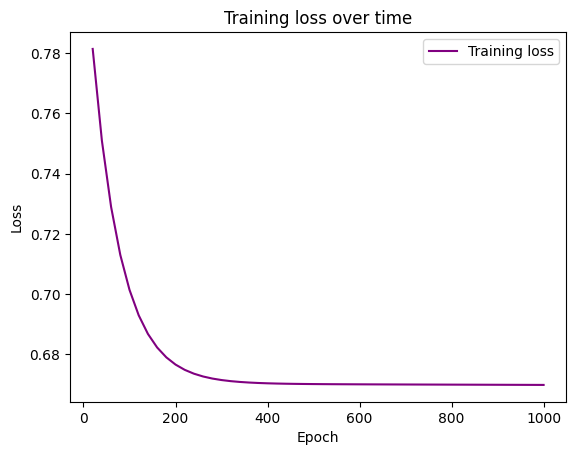

In [21]:
import matplotlib.pyplot as plt

# Plot
epochs = range(20, 1001, 20)
plt.plot(epochs, train_losses, label="Training loss", color="purple")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss over time")
plt.legend()
plt.show()